# 4.4 — Longstaff-Schwartz: valuación de americanas por regresión

3.4 resolvió la parada óptima con un árbol: la envolvente de Snell se calcula hacia atrás porque en la retícula, en cada nodo, se conoce exactamente qué trayectorias pasan por ahí y cuánto vale continuar. Monte Carlo no tiene esa estructura — las trayectorias avanzan hacia adelante y no comparten nodos — y por eso, tal como lo dejamos en 4.1-4.3, sólo servía para europeas. Este notebook cierra esa brecha con el algoritmo de **Longstaff-Schwartz** (2001): la idea de convertir "el valor de continuación en $S_i$" en un problema de **regresión** sobre las trayectorias que ya se simularon, resoluble sin retícula y en cualquier dimensión.

Es la pieza que faltaba para que M4 sea un kit completo de pricing numérico, y la que hace que Monte Carlo alcance a las árboles y PDEs en generalidad: sin LSM, ningún modelo multifactor (Heston, LMM, canastas) puede valuar productos con ejercicio temprano.

## 0. Configuración

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

from qflib.black import bs_price
from qflib.mc import gbm_paths, mc_estimate
from qflib.plotting import apply_style

apply_style()
rng = np.random.default_rng(42)

# Canonical parameters
S0, K, r, q, sigma, T = 100.0, 100.0, 0.05, 0.0, 0.20, 1.0
bs_put = bs_price(S0, K, r, q, sigma, T, "put")
binomial_put = 6.0899899526   # 3.4, arbol CRR americano n=2000, p exacta de no arbitraje

print(f"S0={S0}, K={K}, r={r}, q={q}, sigma={sigma}, T={T}")
print(f"Put europeo (exacto)              = {bs_put:.10f}")
print(f"Put americano (binomial, ref. 3.4) = {binomial_put:.10f}")

S0=100.0, K=100.0, r=0.05, q=0.0, sigma=0.2, T=1.0
Put europeo (exacto)              = 5.5735260223
Put americano (binomial, ref. 3.4) = 6.0899899526


## 1. De la envolvente de Snell a una regresión

En 3.4 §1 la recursión hacia atrás era $V_i = \max\{g(S_i),\ e^{-r\Delta t}\mathbb{E}_i[V_{i+1}]\}$, y el árbol la resolvía porque en cada nodo se conoce la distribución exacta de $S_{i+1}$. En Monte Carlo el objeto que hace falta es el mismo — el **valor de continuación** $C_i(S) = \mathbb{E}\big[D_{i+1}V_{i+1}\mid S_i=S\big]$ —, pero ahora sólo se dispone de $n$ trayectorias simuladas hacia adelante, sin estructura de árbol de la cual leer la esperanza condicional.

La observación de Longstaff-Schwartz es que una esperanza condicional **es una proyección $L^2$**: $C_i(S_i)$ es, por definición, la función medible respecto de $S_i$ que minimiza $\mathbb{E}\big[(D_{i+1}V_{i+1} - h(S_i))^2\big]$ entre todas las $h$. Aproximar esa proyección por la proyección sobre un subespacio de dimensión finita — polinomios de grado $\leq k$ en $S_i$ — convierte el problema en una **regresión de mínimos cuadrados ordinaria** sobre las trayectorias: se regresa el flujo futuro descontado contra una base de $S_i$, y el valor ajustado en cada trayectoria es el estimador de $C_i(S_i)$.

**Tres decisiones de diseño, cada una justificada:**

1. **Regresar sólo sobre trayectorias in-the-money.** Fuera del dinero la decisión es trivial (nunca conviene ejercer lo que vale $0$), así que incluir esos puntos sólo diluye el ajuste donde sí importa — es la recomendación original de Longstaff-Schwartz y la usamos por defecto (`itm_only=True`).
2. **Usar la regresión sólo para decidir, no para valuar.** El precio final se construye acumulando el **flujo realizado** en cada trayectoria (el payoff verdadero en la fecha de ejercicio elegida), nunca el valor ajustado por la regresión. Si se usara el valor ajustado, el ruido de la regresión entraría directo al precio; usado sólo como regla de decisión, un error de ajuste cambia *cuándo* se ejerce pero no *cuánto* se cobra — mucho menos costoso.
3. **El algoritmo hacia atrás, paso a paso:** en $i=N$ el flujo es el payoff terminal. Para $i=N-1,\dots,1$: descontar el flujo un paso, regresar sobre las trayectorias ITM el flujo descontado contra $\{1,S_i,S_i^2,\dots\}$, comparar el ajuste (valor de continuación estimado) contra el payoff intrínseco, y **reemplazar** el flujo de las trayectorias donde conviene ejercer por su payoff intrínseco en $i$. Al final, descontar el último tramo hasta $t_0$ y promediar.

**Los dos sesgos, y por qué el segundo no se ataca en este notebook.** La política que resulta de la regresión es subóptima, así que el estimador que promedia sus propios flujos realizados es **sesgado a la baja**. Pero además hay un sesgo *al alza* si la misma muestra sirve para estimar la política de ejercicio *y* para valuarla — la política "aprende" ligeramente el ruido de esa muestra particular. La solución estándar (Andersen & Broadie, 2004) usa dos muestras independientes — una para calibrar la política, otra para valuarla con esa política fija — y una cota dual que acota el error por arriba; queda referenciado, no implementado aquí.

In [2]:
def longstaff_schwartz(paths, payoff_fn, discount_factors, basis="poly", degree=3, itm_only=True):
    '''Least-squares Monte Carlo price of a Bermudan option (Longstaff & Schwartz, 2001).

    paths: (n_paths, n_dates+1) underlying values, column 0 = t=0.
    payoff_fn: callable S -> intrinsic value, applied elementwise.
    discount_factors: (n_dates,) discount factor from t_i to t_{i-1}, i=1..n_dates.
    basis: "poly" (monomials 1, S, S^2, ..., S^degree).
    itm_only: regress only on in-the-money paths (Longstaff-Schwartz's own recommendation).

    Returns (price, standard_error, exercise_dates_used).
    '''
    if basis != "poly":
        raise ValueError(f"unsupported basis: {basis!r}")
    n_paths, n_cols = paths.shape
    n_dates = n_cols - 1
    if discount_factors.shape != (n_dates,):
        raise ValueError(f"discount_factors must have shape ({n_dates},), got {discount_factors.shape}")

    intrinsic = payoff_fn(paths)               # (n_paths, n_dates+1)
    cashflow = intrinsic[:, -1].copy()         # flujo realizado por trayectoria, se actualiza hacia atras
    exercise_time = np.full(n_paths, n_dates)

    for i in range(n_dates - 1, 0, -1):
        cashflow = cashflow * discount_factors[i]   # descuenta un paso: de t_{i+1} a t_i
        S_i = paths[:, i]
        itm = intrinsic[:, i] > 0.0
        mask = itm if itm_only else np.ones(n_paths, dtype=bool)
        if mask.sum() > degree:                     # suficientes puntos para el ajuste
            design = np.vander(S_i[mask], degree + 1, increasing=True)
            coeffs, *_ = np.linalg.lstsq(design, cashflow[mask], rcond=None)
            continuation = design @ coeffs
            exercise_now = intrinsic[mask, i] > continuation
            idx = np.flatnonzero(mask)[exercise_now]
            cashflow[idx] = intrinsic[idx, i]
            exercise_time[idx] = i

    cashflow = cashflow * discount_factors[0]        # descuenta t_1 -> t_0
    mean, se, _ = mc_estimate(cashflow)
    return mean, se, exercise_time

## 2. Demo 1 — el put americano canónico, y el control duro de una sola fecha

Con $m=50$ fechas de ejercicio (semanal aprox.) y $n=10^5$ trayectorias, LSM debe caer entre el europeo (cota inferior: menos derechos) y el binomial de 3.4 (cota superior: monitoreo continuo de facto con $n=2000$ pasos), dentro de sus propias 3 SE.

Antes de creerle a esa validación conviene un control mucho más duro, porque no depende de ningún ajuste: con **una sola** fecha de ejercicio ($m=1$) no hay decisión que tomar — la única "política" posible es esperar a $T$ — así que LSM debe reproducir el precio europeo simulado sobre las **mismas trayectorias**, a precisión de máquina. Es la comprobación de que la implementación no tiene errores de índices o de descuento, no una comprobación estadística.

In [3]:
m_canonical, n_canonical = 50, 100_000
dt = T / m_canonical
paths_canonical = gbm_paths(S0, r - q, sigma, T, m_canonical, n_canonical, rng)
discount_step = np.full(m_canonical, np.exp(-r * dt))
put_payoff = lambda S: np.maximum(K - S, 0.0)

price_lsm, se_lsm, exercise_time = longstaff_schwartz(paths_canonical, put_payoff, discount_step, degree=3)
print(f"LSM (m={m_canonical}, n={n_canonical:,}, grado 3) = {price_lsm:.6f} +- {3*se_lsm:.6f} (3 SE)")
print(f"  europeo <= LSM <= binomial?  {bs_put:.6f} <= {price_lsm:.6f} <= {binomial_put:.6f}: "
      f"{bs_put <= price_lsm <= binomial_put + 3*se_lsm}")

# control duro: m=1, LSM debe igualar el europeo simulado sobre las MISMAS trayectorias
paths_1 = gbm_paths(S0, r - q, sigma, T, 1, n_canonical, np.random.default_rng(11))
price_1, se_1, _ = longstaff_schwartz(paths_1, put_payoff, np.array([np.exp(-r * T)]), degree=3)
price_european_mc = (np.exp(-r * T) * put_payoff(paths_1[:, -1])).mean()
print(f"\ncontrol duro (m=1): LSM = {price_1:.10f}  |  MC europeo (mismas trayectorias) = {price_european_mc:.10f}")
print(f"  diferencia = {abs(price_1 - price_european_mc):.2e}  (debe ser 0 a precision de maquina)")
assert abs(price_1 - price_european_mc) < 1e-10

LSM (m=50, n=100,000, grado 3) = 6.046522 +- 0.067501 (3 SE)
  europeo <= LSM <= binomial?  5.573526 <= 6.046522 <= 6.089990: True

control duro (m=1): LSM = 5.5799901724  |  MC europeo (mismas trayectorias) = 5.5799901724
  diferencia = 0.00e+00  (debe ser 0 a precision de maquina)


## 3. Demo 2 — la frontera de ejercicio recuperada de la regresión

Para cada fecha $t_i$, el mayor $S_i$ entre las trayectorias que la regresión decidió ejercer aproxima $S^*(t_i)$. No hay ninguna razón estructural para que esto coincida con la frontera del árbol de 3.4 — son dos algoritmos completamente distintos, uno resuelve una retícula y el otro ajusta una regresión sobre trayectorias — así que si las dos coinciden es evidencia fuerte de que LSM aprendió la política correcta, no un artefacto de cómo se implementó.

trayectorias que ejercen antes de T: 40263 de 100,000 (40.3%)


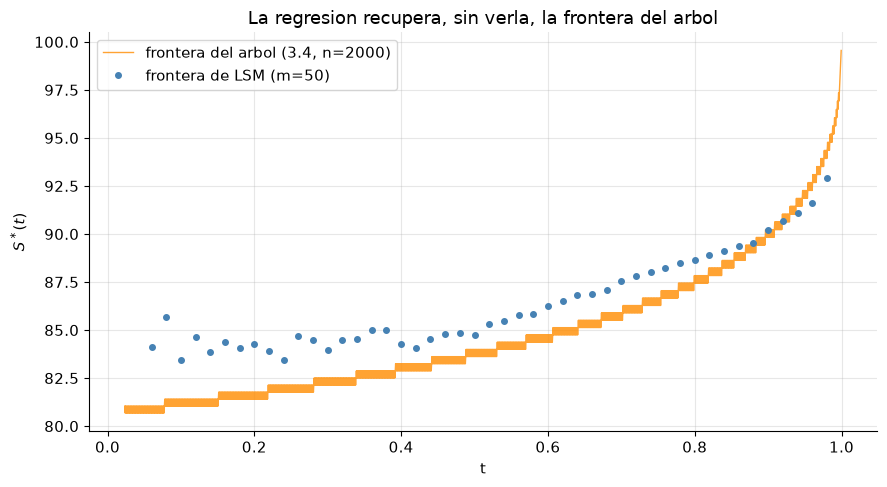

In [4]:
exercise_mask = exercise_time < m_canonical
boundary_lsm = np.full(m_canonical + 1, np.nan)
for i in range(1, m_canonical):
    at_i = exercise_time == i
    if at_i.any():
        boundary_lsm[i] = paths_canonical[at_i, i].max()

# frontera del arbol de 3.4 (misma formula que ahi: CRR con p exacta de no arbitraje)
def crr_boundary(S0, K, r, q, sigma, T, n_steps):
    u = np.exp(sigma * np.sqrt(T / n_steps))
    p = (np.exp((r - q) * (T / n_steps)) - 1.0 / u) / (u - 1.0 / u)
    disc = np.exp(-r * (T / n_steps))
    S_at = lambda i: S0 * u ** (2.0 * np.arange(i + 1) - i)
    V = np.maximum(K - S_at(n_steps), 0.0)
    boundary = np.full(n_steps + 1, np.nan)
    for i in range(n_steps - 1, -1, -1):
        V = disc * (p * V[1:] + (1.0 - p) * V[:-1])
        S_i = S_at(i)
        exercise = np.maximum(K - S_i, 0.0) > V
        if exercise.any():
            j = int(np.flatnonzero(exercise)[-1])
            boundary[i] = S_i[j]
        V = np.maximum(V, np.maximum(K - S_i, 0.0))
    return boundary


n_tree = 2000
boundary_tree = crr_boundary(S0, K, r, q, sigma, T, n_tree)
t_grid_lsm = np.linspace(0, T, m_canonical + 1)
t_grid_tree = np.linspace(0, T, n_tree + 1)

print(f"trayectorias que ejercen antes de T: {exercise_mask.sum()} de {n_canonical:,} "
      f"({exercise_mask.mean():.1%})")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(t_grid_tree, boundary_tree, lw=1.0, color="darkorange", alpha=0.8, label="frontera del arbol (3.4, n=2000)")
ax.plot(t_grid_lsm[1:], boundary_lsm[1:], "o", ms=4, color="steelblue", label=f"frontera de LSM (m={m_canonical})")
ax.set_xlabel("t"); ax.set_ylabel("$S^*(t)$")
ax.set_title("La regresion recupera, sin verla, la frontera del arbol")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Demo 3 — sensibilidad a la base de regresión

¿Cuánto importa el grado del polinomio? Si el algoritmo fuera frágil a esta elección, sería inútil en la práctica — nadie sabe de antemano el grado "correcto" para un producto nuevo. Barremos grado $1$ a $6$ sobre las mismas trayectorias canónicas y esperamos precios consistentes entre sí desde grado $2$ o $3$ en adelante: la robustez de LSM a la base es, junto con su escalamiento en dimensión, la razón de que sea el estándar de la industria para productos con ejercicio temprano.

 grado |     precio |        SE
------------------------------
     1 |   5.965157 |  0.023690
     2 |   6.024691 |  0.022489
     3 |   6.046522 |  0.022500
     4 |   6.044750 |  0.022473
     5 |   6.045913 |  0.022346
     6 |   6.036031 |  0.022033

dispersion entre grados 2..6 (relativa) = 0.3615%


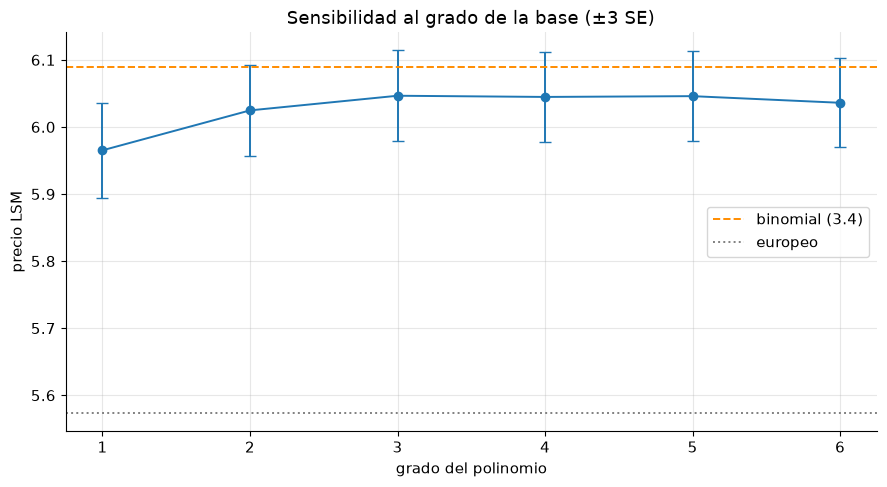

In [5]:
degrees = [1, 2, 3, 4, 5, 6]
prices_by_degree = []
for deg in degrees:
    p, s, _ = longstaff_schwartz(paths_canonical, put_payoff, discount_step, degree=deg)
    prices_by_degree.append((p, s))

print(f"{'grado':>6} | {'precio':>10} | {'SE':>9}")
print("-" * 30)
for deg, (p, s) in zip(degrees, prices_by_degree):
    print(f"{deg:>6} | {p:>10.6f} | {s:>9.6f}")

prices_only = np.array([p for p, _ in prices_by_degree])
spread_degree = (prices_only[1:].max() - prices_only[1:].min()) / prices_only[1:].mean()
print(f"\ndispersion entre grados 2..6 (relativa) = {spread_degree:.4%}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(degrees, prices_only, yerr=[3 * s for _, s in prices_by_degree], fmt="o-", capsize=4)
ax.axhline(binomial_put, color="darkorange", ls="--", label="binomial (3.4)")
ax.axhline(bs_put, color="gray", ls=":", label="europeo")
ax.set_xlabel("grado del polinomio"); ax.set_ylabel("precio LSM")
ax.set_title("Sensibilidad al grado de la base ($\\pm$3 SE)")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Demo 4 — convergencia Bermudan $\to$ americana

Con $m$ fechas de ejercicio equiespaciadas, el precio Bermudan crece monótonamente hacia el americano conforme $m\to\infty$ (más oportunidades de ejercer, nunca menos). En $m=1$ ya verificamos la igualdad exacta con el europeo; aquí se ve la trayectoria completa hasta acercarse al binomial de referencia.

   m |  precio LSM |     +-3SE
------------------------------
   1 |    5.564955 |  0.081926
   2 |    5.824210 |  0.074293
   4 |    5.967434 |  0.071614
   8 |    6.054206 |  0.070078
  16 |    6.067997 |  0.069013
  32 |    6.046288 |  0.067978
  64 |    6.029806 |  0.067581

europeo = 5.573526  |  binomial (americano continuo de facto) = 6.089990


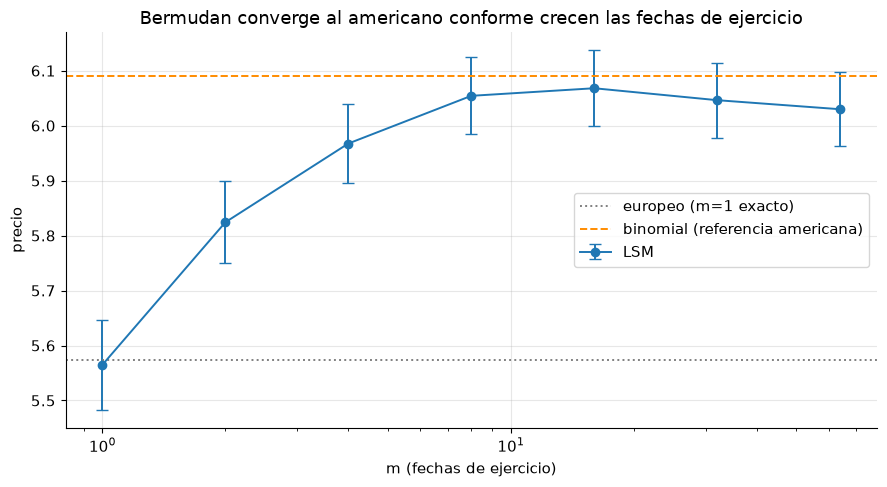

In [6]:
m_grid = [1, 2, 4, 8, 16, 32, 64]
n_conv = 100_000
prices_conv, ses_conv = [], []
rng_conv = np.random.default_rng(77)
for m in m_grid:
    paths_m = gbm_paths(S0, r - q, sigma, T, m, n_conv, rng_conv)
    df_m = np.full(m, np.exp(-r * (T / m)))
    p, s, _ = longstaff_schwartz(paths_m, put_payoff, df_m, degree=3)
    prices_conv.append(p); ses_conv.append(s)

print(f"{'m':>4} | {'precio LSM':>11} | {'+-3SE':>9}")
print("-" * 30)
for m, p, s in zip(m_grid, prices_conv, ses_conv):
    print(f"{m:>4} | {p:>11.6f} | {3*s:>9.6f}")
print(f"\neuropeo = {bs_put:.6f}  |  binomial (americano continuo de facto) = {binomial_put:.6f}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(m_grid, prices_conv, yerr=[3 * s for s in ses_conv], fmt="o-", capsize=4, label="LSM")
ax.axhline(bs_put, color="gray", ls=":", label="europeo (m=1 exacto)")
ax.axhline(binomial_put, color="darkorange", ls="--", label="binomial (referencia americana)")
ax.set_xscale("log")
ax.set_xlabel("m (fechas de ejercicio)"); ax.set_ylabel("precio")
ax.set_title("Bermudan converge al americano conforme crecen las fechas de ejercicio")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Validación

1. **Control duro ($m=1$)**: LSM iguala el MC europeo sobre las mismas trayectorias a `atol=1e-10` (identidad, no test estadístico — ya verificado en la §2, se re-afirma aquí).
2. **Caso canónico ($m=50$)**: `europeo <= LSM` estrictamente (más restricciones nunca vale más) y `LSM <= binomial + 3SE` (el binomial con monitoreo casi continuo es la cota superior práctica).
3. **Precisión relativa**: `|LSM - binomial| / binomial < 1%` en el caso canónico.
4. **QuantLib**: contra `MCAmericanEngine` con los mismos `m`, `n` y grado — mismo algoritmo con implementación independiente —, dentro de 3 SE combinados.
5. **Sensibilidad al grado**: los precios de grado 2 a 6 dentro de 1% entre sí.
6. **Convergencia**: la sucesión de precios Bermudan es monótona no decreciente en $m$ (dentro de tolerancia de ruido MC, comparando medias descontando 1 SE) y el valor en $m=64$ está a menos de 3 SE combinados del binomial.

In [7]:
import QuantLib as ql

# 1. Control duro (re-afirmado)
assert abs(price_1 - price_european_mc) < 1e-10
print(f"m=1: LSM == MC europeo a {abs(price_1 - price_european_mc):.2e} (control duro, sin ruido)")

# 2 y 3. Caso canonico
print(f"europeo ({bs_put:.6f}) <= LSM ({price_lsm:.6f})? {bs_put <= price_lsm}")
assert bs_put <= price_lsm
print(f"LSM <= binomial + 3SE ({binomial_put + 3*se_lsm:.6f})? {price_lsm <= binomial_put + 3*se_lsm}")
assert price_lsm <= binomial_put + 3 * se_lsm
rel_err = abs(price_lsm - binomial_put) / binomial_put
print(f"|LSM - binomial|/binomial = {rel_err:.4%} (<1%? {rel_err < 0.01})")
assert rel_err < 0.01

# 4. QuantLib MCAmericanEngine (mismo algoritmo, implementacion independiente)
eval_date = ql.Date(29, 7, 2026)
ql.Settings.instance().evaluationDate = eval_date
day_count = ql.Actual365Fixed()
calendar = ql.NullCalendar()
maturity = eval_date + int(round(T * 365))
process = ql.BlackScholesMertonProcess(
    ql.QuoteHandle(ql.SimpleQuote(S0)),
    ql.YieldTermStructureHandle(ql.FlatForward(eval_date, q, day_count)),
    ql.YieldTermStructureHandle(ql.FlatForward(eval_date, r, day_count)),
    ql.BlackVolTermStructureHandle(ql.BlackConstantVol(eval_date, calendar, sigma, day_count)))
ql_option = ql.VanillaOption(ql.PlainVanillaPayoff(ql.Option.Put, K), ql.AmericanExercise(eval_date, maturity))
ql_engine = ql.MCAmericanEngine(process, "PseudoRandom", timeSteps=m_canonical, polynomOrder=3,
                                 requiredSamples=n_canonical, seedCalibration=42, seed=42)
ql_option.setPricingEngine(ql_engine)
ql_price, ql_se = ql_option.NPV(), ql_option.errorEstimate()
z_ql = abs(price_lsm - ql_price) / np.sqrt(se_lsm**2 + ql_se**2)
print(f"QuantLib MCAmericanEngine = {ql_price:.6f} +- {ql_se:.6f} | propio = {price_lsm:.6f} +- {se_lsm:.6f} | "
      f"|diff|/SE_comb = {z_ql:.3f} (<=3? {z_ql <= 3.0})")
assert z_ql <= 3.0

# 5. Sensibilidad al grado
print(f"dispersion relativa grados 2..6 = {spread_degree:.4%} (<1%? {spread_degree < 0.01})")
assert spread_degree < 0.01

# 6. Convergencia monotona (con margen de 1 SE de ruido) y cercania al binomial en m=64
for i in range(len(m_grid) - 1):
    assert prices_conv[i] - ses_conv[i] <= prices_conv[i + 1] + ses_conv[i + 1], \
        f"m={m_grid[i]}->{m_grid[i+1]}: la sucesion deberia ser no decreciente (con margen de ruido)"
print("convergencia Bermudan->americana: no decreciente en m (dentro del margen de ruido MC)")
z_m64 = abs(prices_conv[-1] - binomial_put) / np.sqrt(ses_conv[-1]**2)
print(f"m={m_grid[-1]}: |LSM - binomial|/SE = {z_m64:.3f} (<=3? {z_m64 <= 3.0})")
assert z_m64 <= 3.0

print()
print("Validacion completa: 6/6 dentro de tolerancia.")

m=1: LSM == MC europeo a 0.00e+00 (control duro, sin ruido)
europeo (5.573526) <= LSM (6.046522)? True
LSM <= binomial + 3SE (6.157491)? True
|LSM - binomial|/binomial = 0.7138% (<1%? True)
QuantLib MCAmericanEngine = 6.090635 +- 0.021987 | propio = 6.046522 +- 0.022500 | |diff|/SE_comb = 1.402 (<=3? True)
dispersion relativa grados 2..6 = 0.3615% (<1%? True)
convergencia Bermudan->americana: no decreciente en m (dentro del margen de ruido MC)
m=64: |LSM - binomial|/SE = 2.672 (<=3? True)

Validacion completa: 6/6 dentro de tolerancia.


## Referencias

- Longstaff, F.A. & Schwartz, E.S. (2001). *Valuing American Options by Simulation: A Simple Least-Squares Approach*. Review of Financial Studies, 14(1), 113-147.
- Tsitsiklis, J.N. & Van Roy, B. (2001). *Regression Methods for Pricing Complex American-Style Options*. IEEE Transactions on Neural Networks, 12(4), 694-703. (formulación alternativa, contemporánea)
- Andersen, L. & Broadie, M. (2004). *Primal-Dual Simulation Algorithm for Pricing Multi-Dimensional American Options*. Management Science, 50(9), 1222-1234. (cotas duales; corrige el sesgo al alza de reusar la muestra)
- Glasserman, P. (2004). *Monte Carlo Methods in Financial Engineering*, Springer, cap. 8.
- Clément, E., Lamberton, D. & Protter, P. (2002). *An Analysis of a Least Squares Regression Method for American Option Pricing*. Finance and Stochastics, 6(4), 449-471. (convergencia teórica del método).